<a href="https://colab.research.google.com/github/Sergio-Tellz21/upsrj-machine-learning/blob/main/Cancerprediccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
# Carga de base de datos .
data = load_breast_cancer()
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [8]:
X= data.data
y= data.target
features_name= data.feature_names
target_names = data.target_names

In [7]:
#division de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state= 42,
    stratify=y
)

In [11]:
#Creacion y entrenamiento del modelo
model= DecisionTreeClassifier(
    criterion ='gini',
    max_depth= 4,
    random_state = 42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [13]:
# Predicción
y_pred= model.predict(X_test)

In [15]:
#Evaluacion del modelo
print(f"accuracy_score:{accuracy_score(y_test, y_pred)}")
print(f"confusion matrix: {confusion_matrix(y_test, y_pred)}")
print(f"classification report: {classification_report(y_test, y_pred)}")

accuracy_score:0.9239766081871345
confusion matrix: [[ 57   7]
 [  6 101]]
classification report:               precision    recall  f1-score   support

           0       0.90      0.89      0.90        64
           1       0.94      0.94      0.94       107

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171



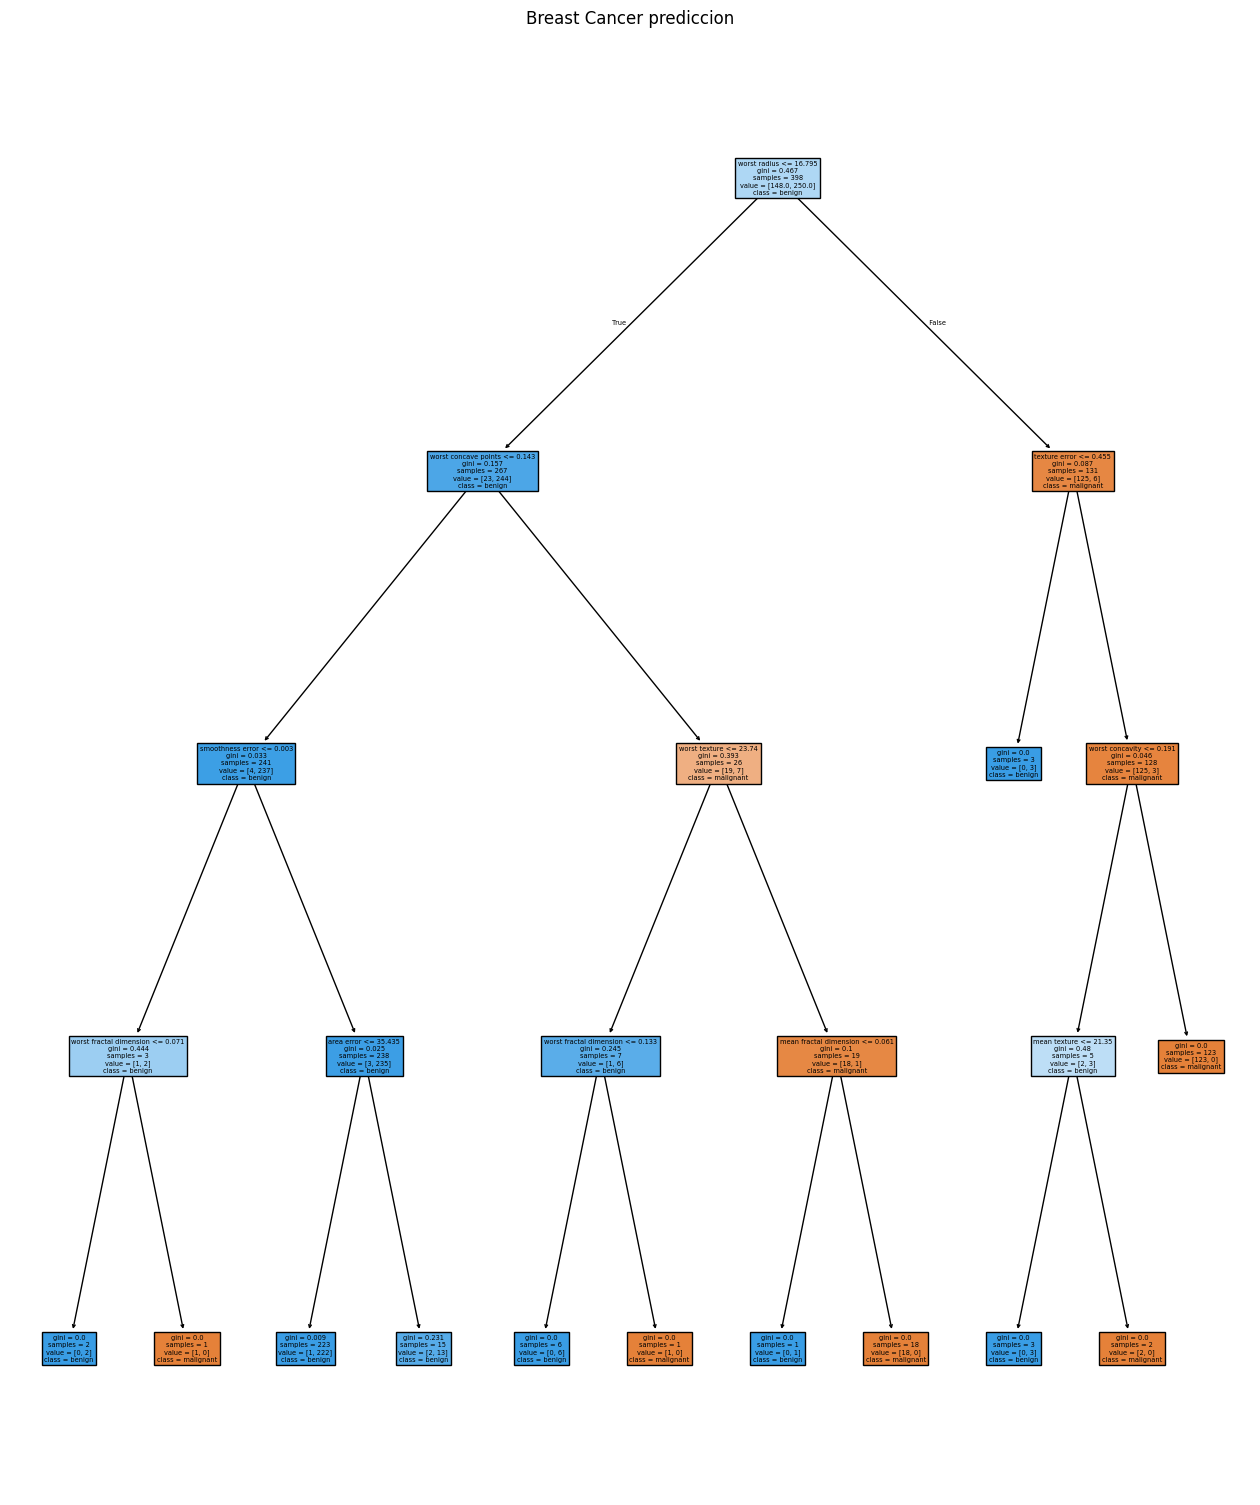

In [22]:
plt.figure(figsize=(16,19))
plot_tree(
    model,
    feature_names = features_name,
    class_names = target_names,
    filled =True
)
plt.title("Breast Cancer prediccion")
plt.show()